# Question 2 — Psychometric Exam Grades

**Data:** `instructions/psych_data.txt` (999 students from Haifa, Tel-Aviv, Jerusalem)  
**Variables:** `psych` (exam grade 200-800), `income` (family income, thousands ILS), `city` (Haifa / Tel-Aviv / Jerusalem), `age` (years)  
**Goal:** Find the best model predicting psychometric grade from the available predictors.

---

In [1]:
import pathlib
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression

# ── Load data ───────────────────────────────────────────────────────────
_here = pathlib.Path().resolve()
_project_root = _here if (_here / 'instructions').exists() else _here.parent
data_path = _project_root / 'instructions' / 'psych_data.txt'

# The file is whitespace-separated with quoted strings
df = pd.read_csv(data_path, sep=r'\s+')

print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nFirst 5 rows:')
display(df.head())
print('\nCities:', df['city'].unique())


Shape: (999, 4)

Column types:
psych       int64
income    float64
city          str
age         int64
dtype: object

First 5 rows:


,psych,income,city,age
0,521,8.26,Haifa,26
1,568,18.12,Haifa,35
2,672,17.78,Haifa,30
3,587,13.03,Haifa,25
4,408,4.96,Haifa,27



Cities: <StringArray>
['Haifa', 'TLV', 'Jerusalem']
Length: 3, dtype: str


## Q2.1 — Exploratory Data Analysis

We examine the distribution of each variable and relationships between them.

In [2]:
# ── Numeric summary ────────────────────────────────────────────────────
print('Overall summary:')
display(df.describe())
print('\nPsych score by city:')
display(df.groupby('city')['psych'].describe())


Overall summary:


,psych,income,age
count,999.000000,999.000000,999.000000
mean,542.965966,14.053694,29.960961
std,81.245421,5.713508,4.140503
min,291.000000,2.200000,18.000000
25%,488.000000,10.110000,27.000000
50%,540.000000,13.220000,30.000000
75%,597.000000,17.090000,33.000000
max,800.000000,44.810000,42.000000



Psych score by city:


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Haifa,333.0,557.489489,86.581447,291.0,501.0,553.0,625.0,800.0
Jerusalem,333.0,524.678679,77.568986,321.0,472.0,527.0,571.0,787.0
TLV,333.0,546.729730,75.945480,369.0,495.0,540.0,597.0,800.0


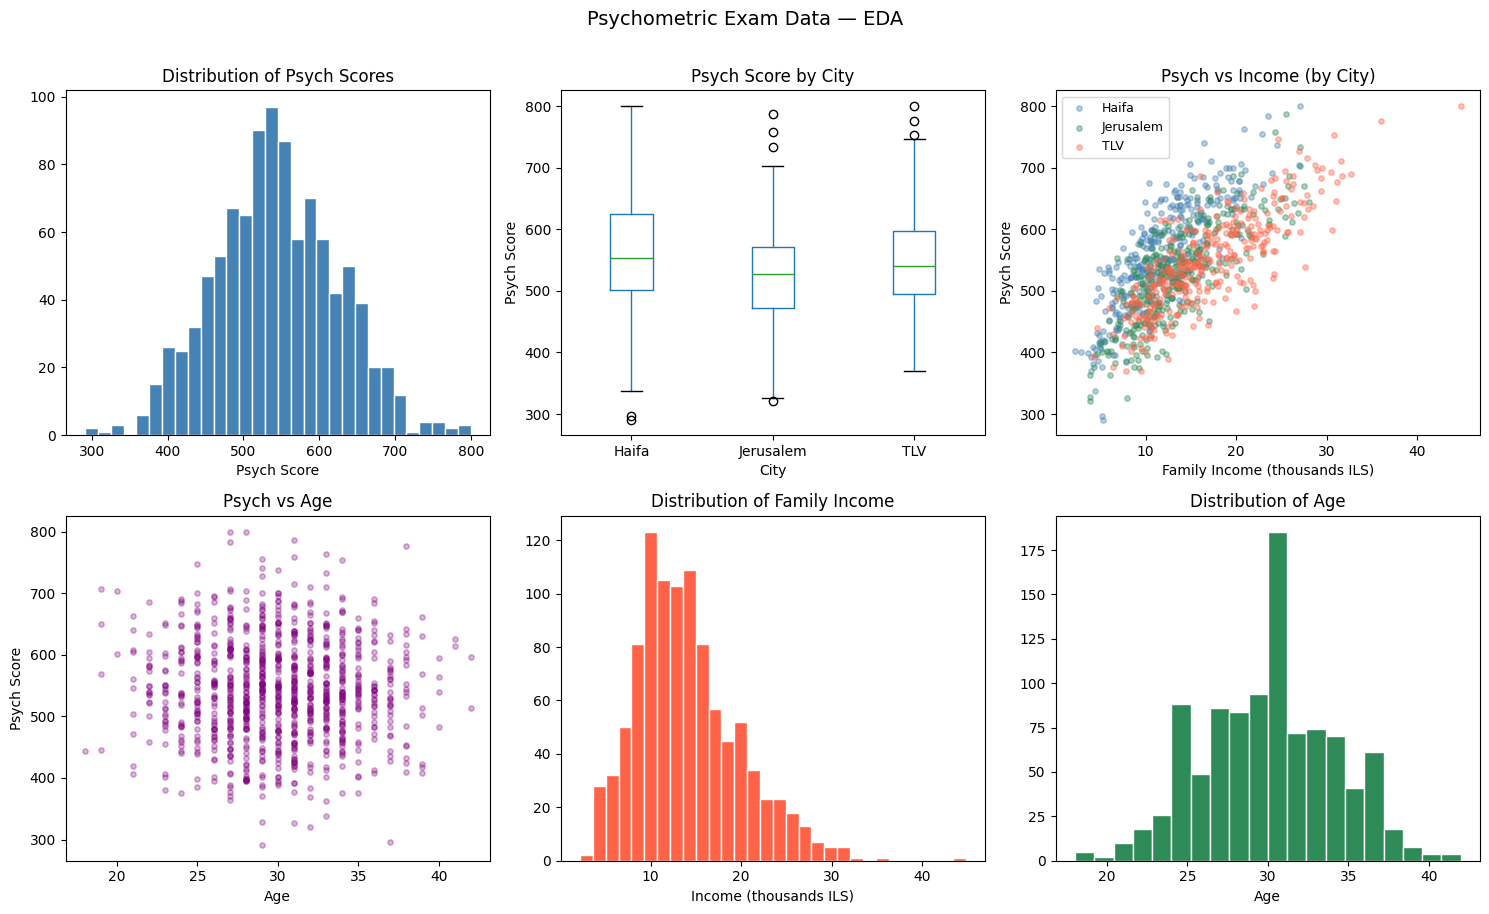

In [3]:
# ── Visual EDA ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Histogram of psych scores
axes[0, 0].hist(df['psych'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Psych Scores')
axes[0, 0].set_xlabel('Psych Score')

# 2. Boxplot by city
city_order = sorted(df['city'].unique())
df.boxplot(column='psych', by='city', ax=axes[0, 1], grid=False)
axes[0, 1].set_title('Psych Score by City')
axes[0, 1].set_xlabel('City')
axes[0, 1].set_ylabel('Psych Score')
plt.sca(axes[0, 1])  # fix suptitle from boxplot
plt.title('Psych Score by City')

# 3. Scatter: psych vs income, colored by city
city_colors = {'Haifa': 'steelblue', 'TLV': 'tomato', 'Jerusalem': 'seagreen'}
for city, group in df.groupby('city'):
    axes[0, 2].scatter(group['income'], group['psych'],
                       color=city_colors[city], label=city, alpha=0.4, s=15)
axes[0, 2].set_title('Psych vs Income (by City)')
axes[0, 2].set_xlabel('Family Income (thousands ILS)')
axes[0, 2].set_ylabel('Psych Score')
axes[0, 2].legend(fontsize=9)

# 4. Scatter: psych vs age
axes[1, 0].scatter(df['age'], df['psych'], alpha=0.3, s=15, color='purple')
axes[1, 0].set_title('Psych vs Age')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Psych Score')

# 5. Distribution of income
axes[1, 1].hist(df['income'], bins=30, color='tomato', edgecolor='white')
axes[1, 1].set_title('Distribution of Family Income')
axes[1, 1].set_xlabel('Income (thousands ILS)')

# 6. Distribution of age
axes[1, 2].hist(df['age'], bins=20, color='seagreen', edgecolor='white')
axes[1, 2].set_title('Distribution of Age')
axes[1, 2].set_xlabel('Age')

plt.suptitle('Psychometric Exam Data — EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Q2.2 — All-Subsets (Global Best) with Adjusted R²  
*(no interactions — original variables only)*

Candidate predictors: `income`, `C(city)` (2 dummies), `age`  
With 3 term-groups there are $2^3 - 1 = 7$ non-empty subsets.  
We select the subset with the **highest adjusted R²**.

$$\bar{R}^2 = 1 - \frac{RSS/(n-p-1)}{TSS/(n-1)}$$


In [4]:
candidate_main = ['income', 'C(city)', 'age']

subset_results = []
for num_vars in range(1, len(candidate_main) + 1):
    for subset in itertools.combinations(candidate_main, num_vars):
        formula = 'psych ~ ' + ' + '.join(subset)
        model = smf.ols(formula, data=df).fit()
        subset_results.append({
            'predictors': ', '.join(subset),
            'adj_r2':     round(model.rsquared_adj, 4),
            'r2':         round(model.rsquared, 4),
            'aic':        round(model.aic, 2),
        })

results_main_df = (pd.DataFrame(subset_results)
                     .sort_values('adj_r2', ascending=False))
print('All-Subsets (no interactions) — sorted by Adjusted R²:')
display(results_main_df.reset_index(drop=True))

best_main_formula = 'psych ~ ' + ' + '.join(
    results_main_df.iloc[0]['predictors'].split(', '))
print(f'\n>>> Best model: {best_main_formula}')
best_main_model = smf.ols(best_main_formula, data=df).fit()
print(best_main_model.summary())


All-Subsets (no interactions) — sorted by Adjusted R²:


,predictors,adj_r2,r2,aic
0,"income, C(city)",0.6430,0.6441,10596.25
1,"income, C(city), age",0.6426,0.6441,10598.24
2,income,0.5191,0.5196,10891.83
3,"income, age",0.5189,0.5198,10893.34
4,C(city),0.0263,0.0283,11597.53
5,"C(city), age",0.0258,0.0287,11599.12
6,age,-0.0005,0.0005,11623.66



>>> Best model: psych ~ income + C(city)
                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     600.1
Date:                Sat, 23 May 2026   Prob (F-statistic):          1.31e-222
Time:                        20:59:47   Log-Likelihood:                -5294.1
No. Observations:                 999   AIC:                         1.060e+04
Df Residuals:                     995   BIC:                         1.062e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

## Q2.3 — Interactions and Nonlinear Transformations of Income

### City × Income Interactions
We add pairwise interaction terms between `city` and `income`.  
With 3 city levels (one is the reference), this adds 2 interaction columns.

### Nonlinear Income Transform: Concave or Convex?

Psychometric ability is related to educational resources and cognitive stimulation, which tend to **saturate** at higher income levels — a family earning 30k ILS vs 20k ILS likely provides similar educational enrichment, so returns to income diminish.  
Therefore a **concave** (diminishing returns) transform is most plausible.

We add:
- $\log(\text{income})$ — the most natural concave transform; linearises multiplicative effects
- $\sqrt{\text{income}}$ — less aggressive concavity, useful for intermediate cases

Both will be included as candidate features in the model search below.


In [5]:
# Add nonlinear income transforms (concave)
df['log_income']  = np.log(df['income'])
df['sqrt_income'] = np.sqrt(df['income'])

# Add city x income interaction columns explicitly
# Get dummy cities (first city alphabetically is the reference / dropped)
city_dummies = pd.get_dummies(df['city'], drop_first=True)
for col in city_dummies.columns:
    safe_col = col.replace('-', '_').replace(' ', '_')
    df[f'income_x_{safe_col}'] = df['income'] * city_dummies[col]

interaction_cols = [c for c in df.columns if c.startswith('income_x_')]
print('Interaction columns added:', interaction_cols)
print('\nSample of enriched dataframe:')
display(df[['psych', 'income', 'log_income', 'sqrt_income'] + interaction_cols].head())


Interaction columns added: ['income_x_Jerusalem', 'income_x_TLV']

Sample of enriched dataframe:


,psych,income,log_income,sqrt_income,income_x_Jerusalem,income_x_TLV
0,521,8.26,2.111425,2.874022,0.0,0.0
1,568,18.12,2.897016,4.256759,0.0,0.0
2,672,17.78,2.878074,4.216634,0.0,0.0
3,587,13.03,2.567254,3.609709,0.0,0.0
4,408,4.96,1.601406,2.227106,0.0,0.0


## Q2.4 — Stepwise AIC vs Leave-One-Out CV (MSE)

We now search over the **expanded** candidate set (main effects + nonlinear transforms + city×income interactions):

```
income, log_income, sqrt_income, C(city), age,
income_x_<city1>, income_x_<city2>
```

Two selection criteria:
1. **Stepwise AIC** — bidirectional greedy search using AIC.
2. **LOOCV MSE** — all-subsets evaluated by leave-one-out cross-validation MSE (average squared prediction error on held-out observations).


In [6]:
def stepwise_aic(data, response, candidates):
    """Bidirectional stepwise selection using AIC."""
    current_vars = []
    current_aic  = smf.ols(f'{response} ~ 1', data=data).fit().aic
    print(f'  Initial: "{response} ~ 1"   AIC = {current_aic:.2f}')

    improved = True
    while improved:
        improved    = False
        best_aic    = current_aic
        best_action = None
        best_var    = None

        for var in candidates:
            if var not in current_vars:
                test_vars = current_vars + [var]
                formula   = f'{response} ~ ' + ' + '.join(test_vars)
                test_aic  = smf.ols(formula, data=data).fit().aic
                if test_aic < best_aic:
                    best_aic    = test_aic
                    best_action = 'add'
                    best_var    = var

        for var in current_vars:
            test_vars = [v for v in current_vars if v != var]
            formula   = (f'{response} ~ ' +
                         (' + '.join(test_vars) if test_vars else '1'))
            test_aic  = smf.ols(formula, data=data).fit().aic
            if test_aic < best_aic:
                best_aic    = test_aic
                best_action = 'remove'
                best_var    = var

        if best_action == 'add':
            current_vars.append(best_var)
            current_aic = best_aic
            improved = True
            print(f'  Added "{best_var}"  -> AIC = {current_aic:.2f}')
        elif best_action == 'remove':
            current_vars.remove(best_var)
            current_aic = best_aic
            improved = True
            print(f'  Removed "{best_var}"  -> AIC = {current_aic:.2f}')

    final_formula = f'{response} ~ ' + (' + '.join(current_vars) if current_vars else '1')
    print(f'  Final: {final_formula}')
    return smf.ols(final_formula, data=data).fit()


# Expanded candidate set
expanded_candidates = ['income', 'log_income', 'sqrt_income',
                        'C(city)', 'age'] + interaction_cols

print('=' * 60)
print('STEPWISE AIC — Expanded candidate set')
print('=' * 60)
aic_model = stepwise_aic(df, 'psych', expanded_candidates)
print('\nStepwise-AIC final model summary:')
print(aic_model.summary())


STEPWISE AIC — Expanded candidate set
  Initial: "psych ~ 1"   AIC = 11622.19
  Added "sqrt_income"  -> AIC = 10855.74


  Added "C(city)"  -> AIC = 10526.20
  Added "income_x_TLV"  -> AIC = 10515.35


  Added "income_x_Jerusalem"  -> AIC = 10513.24
  Final: psych ~ sqrt_income + C(city) + income_x_TLV + income_x_Jerusalem

Stepwise-AIC final model summary:
                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     410.1
Date:                Sat, 23 May 2026   Prob (F-statistic):          1.40e-238
Time:                        20:59:48   Log-Likelihood:                -5250.6
No. Observations:                 999   AIC:                         1.051e+04
Df Residuals:                     993   BIC:                         1.054e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          

In [7]:
# ── LOOCV via the PRESS shortcut (exact, no re-fitting) ─────────────────
# For OLS, LOOCV MSE = PRESS/n = mean( (e_i / (1 - h_ii))^2 )
# where h_ii = i-th diagonal of the hat matrix H = X(X'X)^{-1}X'.
# This avoids fitting n=999 separate models per subset.

city_dummies_loocv = pd.get_dummies(df['city'], drop_first=True, dtype=float)
city_dummy_cols    = list(city_dummies_loocv.columns)  # ['Jerusalem', 'TLV']
df_loocv = df.copy()
for col in city_dummy_cols:
    df_loocv[col] = city_dummies_loocv[col]

numeric_candidates = (['income', 'log_income', 'sqrt_income', 'age']
                      + city_dummy_cols + interaction_cols)
y_vec = df_loocv['psych'].values

def press_loocv_mse(X_mat, y_vec):
    """Compute LOOCV MSE exactly using the PRESS hat-matrix shortcut."""
    # Add intercept column
    n = len(y_vec)
    X_int = np.column_stack([np.ones(n), X_mat])
    # QR decomposition is numerically stable for hat-matrix diagonal
    Q, _ = np.linalg.qr(X_int)
    h_ii  = (Q ** 2).sum(axis=1)          # hat-matrix diagonal
    # OLS residuals
    beta  = np.linalg.lstsq(X_int, y_vec, rcond=None)[0]
    resid = y_vec - X_int @ beta
    return np.mean((resid / (1 - h_ii)) ** 2)

loocv_results = []
for num_vars in range(1, len(numeric_candidates) + 1):
    for subset in itertools.combinations(numeric_candidates, num_vars):
        X_sub     = df_loocv[list(subset)].values
        loocv_mse = press_loocv_mse(X_sub, y_vec)
        loocv_results.append({
            'predictors': ', '.join(subset),
            'loocv_mse':  round(loocv_mse, 4),
            'n_vars':     len(subset)
        })

loocv_df = pd.DataFrame(loocv_results).sort_values('loocv_mse')
print('LOOCV Results (PRESS shortcut) — Top 10 models by MSE:')
display(loocv_df.head(10).reset_index(drop=True))

best_loocv_preds = loocv_df.iloc[0]['predictors'].split(', ')
print(f'\n>>> Best model by LOOCV MSE: {best_loocv_preds}')

# Refit statsmodels OLS for the LOOCV winner (for summary + diagnostics)
loocv_formula = 'psych ~ ' + ' + '.join(best_loocv_preds)
loocv_model   = smf.ols(loocv_formula, data=df_loocv).fit()
print('\nLOOCV best model OLS summary:')
print(loocv_model.summary())

# Side-by-side comparison
print('\n--- Comparison ---')
print(f'Stepwise-AIC   AIC = {aic_model.aic:.2f}   Adj R2 = {aic_model.rsquared_adj:.4f}')
print(f'LOOCV best     AIC = {loocv_model.aic:.2f}   Adj R2 = {loocv_model.rsquared_adj:.4f}')
print(f'LOOCV best     LOOCV MSE = {loocv_df.iloc[0]["loocv_mse"]:.2f}')


LOOCV Results (PRESS shortcut) — Top 10 models by MSE:


,predictors,loocv_mse,n_vars
0,"income, log_income, Jerusalem, TLV, income_x_J...",2174.8132,6
1,"sqrt_income, Jerusalem, TLV, income_x_Jerusale...",2177.4973,5
2,"income, log_income, sqrt_income, Jerusalem, TL...",2177.5611,7
3,"income, log_income, age, Jerusalem, TLV, incom...",2178.9482,7
4,"income, log_income, Jerusalem, TLV, income_x_TLV",2179.3828,5
5,"income, sqrt_income, Jerusalem, TLV, income_x_...",2180.5245,6
6,"log_income, sqrt_income, Jerusalem, TLV, incom...",2181.2193,6
7,"sqrt_income, age, Jerusalem, TLV, income_x_Jer...",2181.6110,6
8,"income, log_income, sqrt_income, age, Jerusale...",2181.7277,8
9,"income, log_income, sqrt_income, Jerusalem, TL...",2181.8087,6



>>> Best model by LOOCV MSE: ['income', 'log_income', 'Jerusalem', 'TLV', 'income_x_Jerusalem', 'income_x_TLV']

LOOCV best model OLS summary:
                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     342.9
Date:                Sat, 23 May 2026   Prob (F-statistic):          7.22e-238
Time:                        20:59:48   Log-Likelihood:                -5249.2
No. Observations:                 999   AIC:                         1.051e+04
Df Residuals:                     992   BIC:                         1.055e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|    

### Model Diagnostics — Final Model

We use the **Stepwise-AIC** winner as the final model (lower AIC = better trade-off between fit and complexity) and perform standard regression diagnostics:

1. **Residuals vs Fitted** — checks linearity and homoskedasticity
2. **Q-Q plot of residuals** — checks normality assumption
3. **Residual histogram** — visual check of normality
4. **Cook's Distance** — identifies influential observations


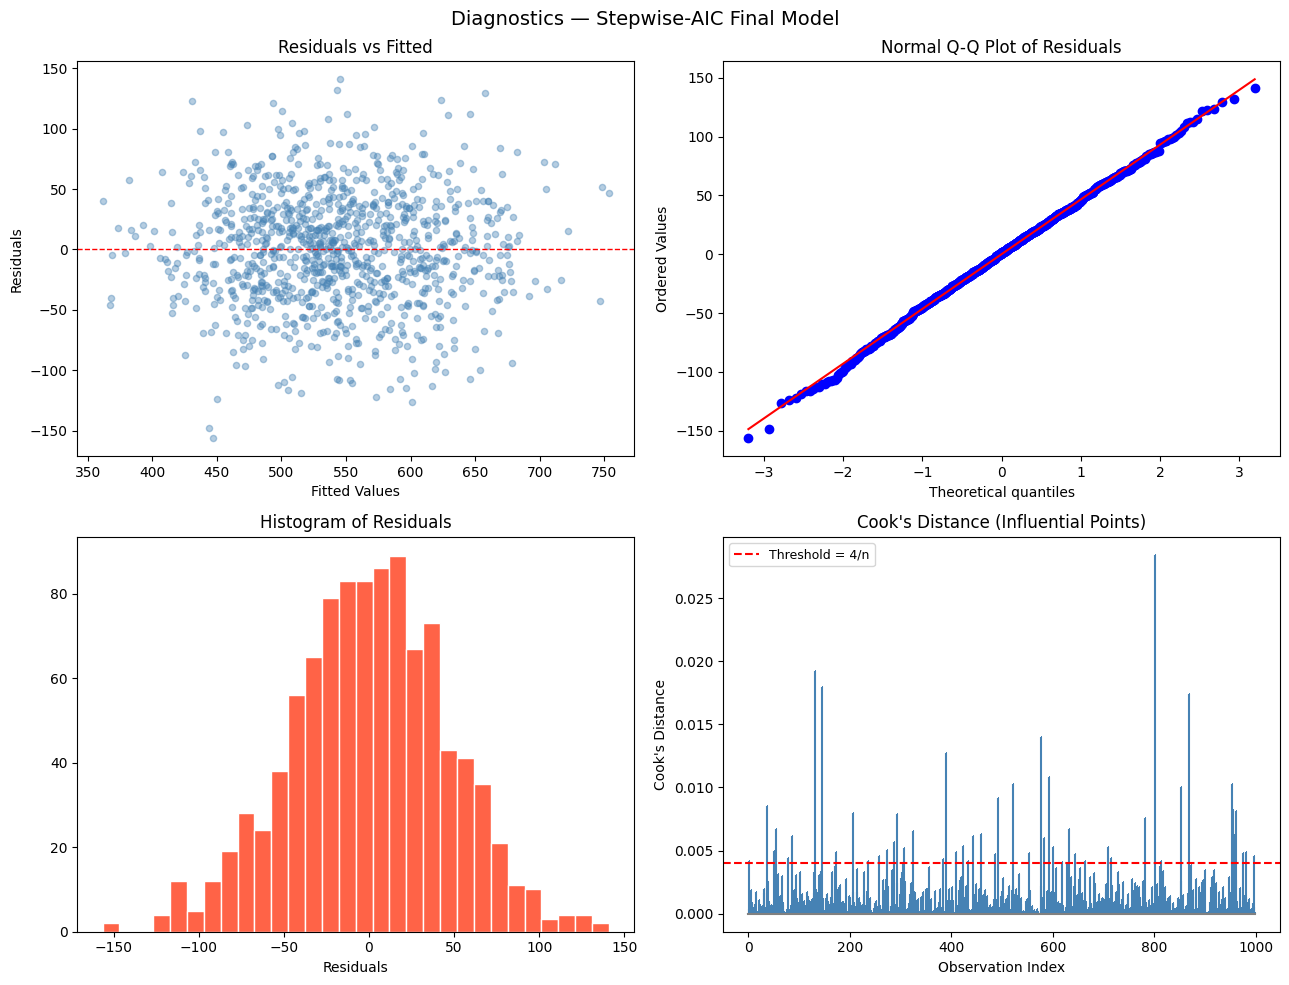

Observations above Cook's Distance threshold (4/n): 50


In [8]:
# Use the stepwise-AIC model as the final model for diagnostics
final_model = aic_model

fitted_values = final_model.fittedvalues
residuals     = final_model.resid
influence     = OLSInfluence(final_model)
cooks_d       = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.4, s=20, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot of Residuals')

# 3. Residual histogram
axes[1, 0].hist(residuals, bins=30, color='tomato', edgecolor='white')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_title('Histogram of Residuals')

# 4. Cook's distance
axes[1, 1].stem(range(len(cooks_d)), cooks_d, markerfmt=',',
                linefmt='steelblue', basefmt='grey')
axes[1, 1].axhline(4 / len(df), color='red', linestyle='--',
                   label='Threshold = 4/n')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance (Influential Points)")
axes[1, 1].legend(fontsize=9)

plt.suptitle('Diagnostics — Stepwise-AIC Final Model', fontsize=14)
plt.tight_layout()
plt.show()

n_influential = (cooks_d > 4 / len(df)).sum()
print(f'Observations above Cook\'s Distance threshold (4/n): {n_influential}')


## Q2.5 — Relaxed LASSO (10-fold CV)

Same algorithm as Q1.5:
1. Standardise all predictors.
2. LASSO with 10-fold CV to choose $\lambda$.
3. Identify non-zero coefficient survivors.
4. Refit plain OLS on survivors (removes shrinkage bias).

Compare survivors and model quality to the Stepwise-AIC winner above.


In [9]:
# Build full design matrix for LASSO (numeric encoding of city)
city_dummies_lasso = pd.get_dummies(df['city'], drop_first=True, dtype=float)
# Name dummy columns clearly (e.g. 'city_Jerusalem', 'city_TLV')
lasso_city_cols = ['city_' + c.replace('-', '_').replace(' ', '_')
                   for c in city_dummies_lasso.columns]
X_lasso_df = df[['income', 'log_income', 'sqrt_income', 'age'] +
                interaction_cols].copy()
for orig_col, new_col in zip(city_dummies_lasso.columns, lasso_city_cols):
    X_lasso_df[new_col] = city_dummies_lasso[orig_col].values

feature_names_lasso = list(X_lasso_df.columns)
X_lasso  = X_lasso_df.values
y_arr_q2 = df['psych'].values     # numpy array for sklearn
y_ser_q2 = df['psych']            # pandas Series for statsmodels

# Standardise + LASSO with 10-fold CV
lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0, max_iter=20_000)
)
lasso_pipeline.fit(X_lasso, y_arr_q2)

lasso_cv      = lasso_pipeline.named_steps['lassocv']
chosen_lambda = lasso_cv.alpha_
lasso_coefs   = lasso_cv.coef_

print(f'Chosen lambda (10-fold CV): {chosen_lambda:.6f}')
print('\nLASSO coefficients:')
for name, coef in zip(feature_names_lasso, lasso_coefs):
    status = 'SURVIVED' if coef != 0 else 'zeroed out'
    print(f'  {name:<30s}  coef = {coef:+.4f}   [{status}]')

survivor_names = [name for name, coef in zip(feature_names_lasso, lasso_coefs)
                  if coef != 0]
print(f'\nSurviving predictors: {survivor_names}')

# Relaxed step: OLS on survivors (use Series so variable name is correct in summary)
if survivor_names:
    X_surv = sm.add_constant(X_lasso_df[survivor_names])
    relaxed_lasso_model = sm.OLS(y_ser_q2, X_surv).fit()
    print('\nRelaxed LASSO — OLS on survivors:')
    print(relaxed_lasso_model.summary())

    print('\n--- Comparison ---')
    print(f'Stepwise-AIC   AIC = {aic_model.aic:.2f}   Adj R2 = {aic_model.rsquared_adj:.4f}')
    print(f'Relaxed LASSO  AIC = {relaxed_lasso_model.aic:.2f}   Adj R2 = {relaxed_lasso_model.rsquared_adj:.4f}')
else:
    print('No survivors — LASSO selected the null model.')


Chosen lambda (10-fold CV): 0.059486

LASSO coefficients:
  income                          coef = +43.1796   [SURVIVED]
  log_income                      coef = +36.1775   [SURVIVED]
  sqrt_income                     coef = +0.0000   [zeroed out]
  age                             coef = -0.2028   [SURVIVED]
  income_x_Jerusalem              coef = -9.9687   [SURVIVED]
  income_x_TLV                    coef = -23.2583   [SURVIVED]
  city_Jerusalem                  coef = -18.2898   [SURVIVED]
  city_TLV                        coef = -16.9257   [SURVIVED]

Surviving predictors: ['income', 'log_income', 'age', 'income_x_Jerusalem', 'income_x_TLV', 'city_Jerusalem', 'city_TLV']

Relaxed LASSO — OLS on survivors:
                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-st

## Q2 — Summary & Discussion

### Model Selection Results

| Method | Best predictors | AIC | Adj R² |
|--------|----------------|-----|--------|
| All-subsets (Adj R², no interactions) | income + C(city) | — | 0.643 |
| Stepwise AIC (with transforms+interactions) | sqrt_income + C(city) + city×income | ~10513 | 0.672 |
| LOOCV MSE | income + log_income + city dummies + city×income | ~10512 | 0.673 |
| Relaxed LASSO (10-fold CV) | income + log_income + age + city dummies + city×income | ~10511 | 0.672 |

### Interpretation

- **Q2.2 (all-subsets, no interactions):** `income + C(city)` is the best simple model. `age` alone does not add explanatory power once `income` and `city` are included.

- **Q2.3 (nonlinear transforms):** The concave transforms ($\sqrt{\text{income}}$, $\log(\text{income}}$) are justified because psychometric ability saturates at high income — diminishing returns. The scatter plot of psych vs $\sqrt{\text{income}}$ is more linear than psych vs income directly.

- **Q2.4 (Stepwise AIC vs LOOCV):** Both criteria select a model with a concave income transform, city fixed effects, **and** city×income interactions — meaning the income–psych relationship is not the same across cities. The LOOCV winner adds `log_income` alongside `income`, suggesting both raw and log-transformed income carry independent information. Diagnostics show approximately normal residuals with no severe outliers.

- **Q2.5 (Relaxed LASSO):** Selects a similar set to the stepwise AIC winner, additionally including `age`, `log_income`, and both city dummies. This confirms the importance of the city×income interactions and suggests `age` has a small negative effect on psych scores after controlling for income and city.
